# Titanic Machine Learning Pipeline
Welcome! This notebook demonstrates a complete, beginner-friendly Machine Learning pipeline using the famous Titanic dataset. Our goal is to predict whether a passenger survived (1) or did not survive (0).

We will walk through 10 essential steps:
1. Data Understanding
2. Data Cleaning
3. Exploratory Data Analysis (EDA)
4. Feature Engineering
5. Encoding Categorical Variables
6. Feature Selection
7. Train-Test Split
8. Model Building
9. Model Evaluation
10. Model Improvements

## 1. Data Understanding
First, let's load our data and take a look at it. This step helps us understand what information is available to us.

**Features in the dataset:**
- **Survived**: Target variable (0 = No, 1 = Yes)
- **Pclass**: Ticket class (1 = 1st, 2 = 2nd, 3 = 3rd)
- **Name**: Passenger's name
- **Sex**: Passenger's sex
- **Age**: Passenger's age in years
- **SibSp**: Number of siblings/spouses aboard the Titanic
- **Parch**: Number of parents/children aboard the Titanic
- **Ticket**: Ticket number
- **Fare**: Passenger fare
- **Cabin**: Cabin number
- **Embarked**: Port of Embarkation (C = Cherbourg, Q = Queenstown, S = Southampton)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('Titanic-Dataset.csv')

# Show the shape (number of rows and columns)
print(f"Dataset Shape: {df.shape[0]} rows and {df.shape[1]} columns.\n")

# Show basic info and data types
print("Data Types and Non-Null Counts:")
df.info()

# Preview the first few rows
df.head()

Dataset Shape: 891 rows and 12 columns.

Data Types and Non-Null Counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 2. Data Cleaning
Real-world data is rarely perfect. Some information might be missing. We need to handle this before training our model.

- **Age**: We will fill missing values with the median age. The median is robust to extreme outliers compared to the mean (average).
- **Embarked**: We will fill missing values with the mode (most common value).
- **Cabin**: We will drop this column entirely because it has too many missing values to be useful.

In [ ]:
# Check missing values
print("Missing values before cleaning:")
print(df.isnull().sum())

# 1. Fill missing 'Age' with the median age
df['Age'] = df['Age'].fillna(df['Age'].median())

# 2. Fill missing 'Embarked' with the most frequent value (mode)
mode_embarked = df['Embarked'].mode()[0]
df['Embarked'] = df['Embarked'].fillna(mode_embarked)

# 3. Drop the 'Cabin' column
df = df.drop(columns=['Cabin'])

print("\nMissing values after cleaning:")
print(df.isnull().sum())

Missing values before cleaning:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Missing values after cleaning:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


## 3. Exploratory Data Analysis (EDA)
Let's explore the relationships between different features and survival. Visualizations help us intuitively grasp patterns.

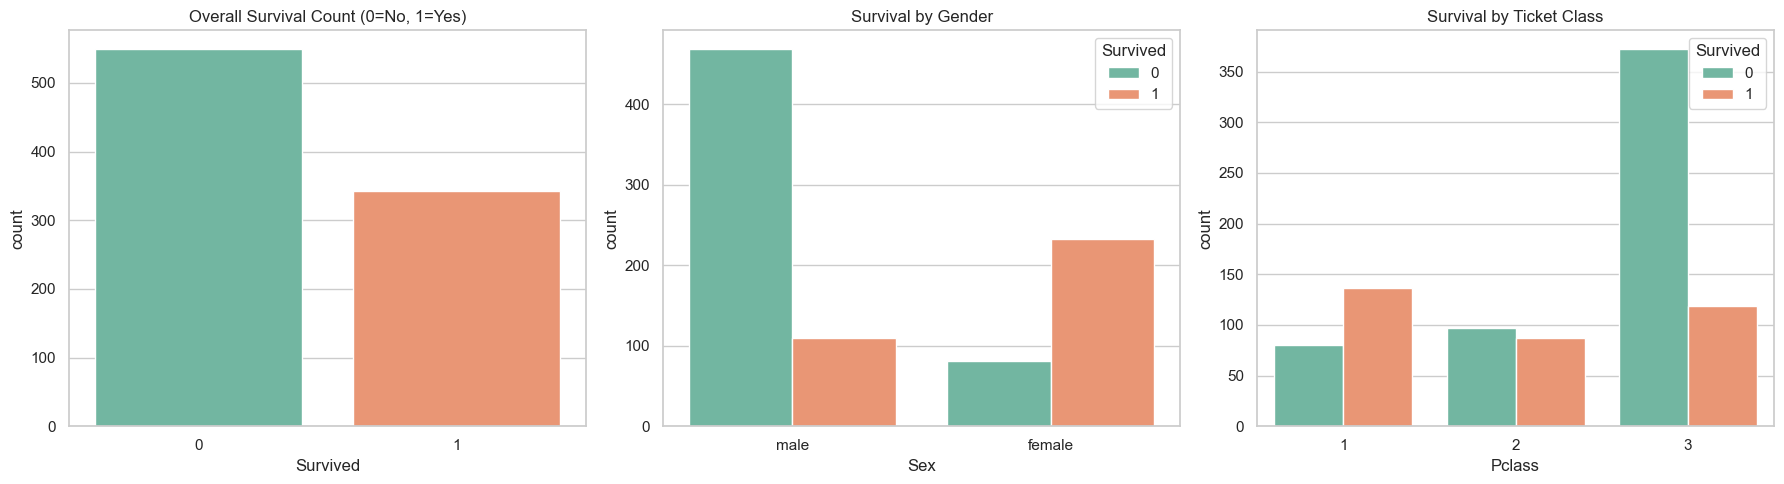

c:\Users\Hp\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


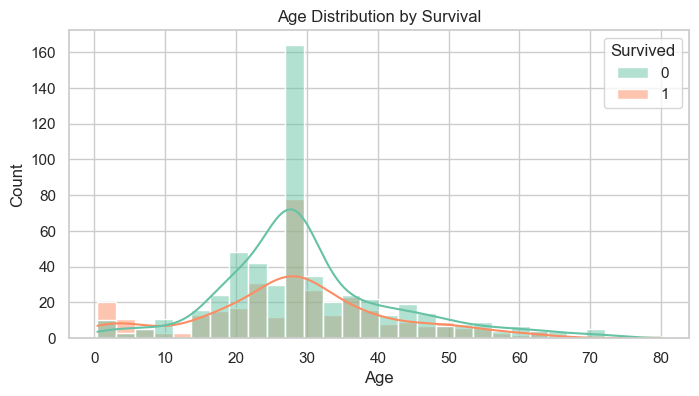

In [ ]:
# Set the plotting style
sns.set_theme(style="whitegrid")

# Create a figure with subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Use a string version of Survived for plotting hue to prevent matplotlib legend errors
plot_df = df.copy()
plot_df['Survived'] = plot_df['Survived'].astype(str)

# 1. Overall Survival Rate
sns.countplot(data=plot_df, x='Survived', ax=axes[0], palette='Set2')
axes[0].set_title('Overall Survival Count (0=No, 1=Yes)')

# 2. Gender vs Survival
sns.countplot(data=plot_df, x='Sex', hue='Survived', ax=axes[1], palette='Set2')
axes[1].set_title('Survival by Gender')

# 3. Class vs Survival
sns.countplot(data=plot_df, x='Pclass', hue='Survived', ax=axes[2], palette='Set2')
axes[2].set_title('Survival by Ticket Class')

plt.tight_layout()
plt.show()

# Age Distribution
plt.figure(figsize=(8, 4))
sns.histplot(data=plot_df, x='Age', hue='Survived', bins=30, kde=True, palette='Set2')
plt.title('Age Distribution by Survival')
plt.show()

## 4. Feature Engineering
Feature engineering means creating new, meaningful columns from the existing ones. This can help our model find better patterns.

- **FamilySize**: Sum of siblings/spouses and parents/children (+1 for the passenger themselves).
- **IsAlone**: A flag indicating if the passenger was traveling completely alone.
- **Title**: Extracting titles (Mr., Mrs., etc.) from the Name feature so the model can capture social status.
- **AgeGroup**: Grouping ages into intuitive categories (Child, Adult, Senior).

In [ ]:
# 1. Family Size
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

# 2. IsAlone (1 if alone, 0 otherwise)
df['IsAlone'] = 0
df.loc[df['FamilySize'] == 1, 'IsAlone'] = 1

# 3. Title Extraction (Takes the word ending in a period from the Name)
# Using a raw string (r'...') prevents potential regular expression escape sequence warnings
df['Title'] = df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)

# Group rare titles
common_titles = ['Mr', 'Miss', 'Mrs', 'Master']
df['Title'] = df['Title'].apply(lambda x: x if x in common_titles else 'Rare')

# 4. Age Groups
bins = [0, 12, 60, 100]
labels = ['Child', 'Adult', 'Senior']
df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels)

df[['Name', 'Title', 'Age', 'AgeGroup', 'FamilySize', 'IsAlone']].head()

,Name,Title,Age,AgeGroup,FamilySize,IsAlone
0,"Braund, Mr. Owen Harris",Mr,22.0,Adult,2,0
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",Mrs,38.0,Adult,2,0
2,"Heikkinen, Miss. Laina",Miss,26.0,Adult,1,1
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",Mrs,35.0,Adult,2,0
4,"Allen, Mr. William Henry",Mr,35.0,Adult,1,1


## 5. Encoding Categorical Variables
Models can only understand numbers! We must translate text (like "Male" or "Female") into numbers.

- **Label Encoding**: For binary categories (Sex: male->0, female->1).
- **One-Hot Encoding**: For categories without inherent order (Embarked, Title, AgeGroup). This creates new binary columns for each category value.

In [ ]:
# 1. Label Encode 'Sex'
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

# 2. One-Hot Encode 'Embarked', 'Title', 'AgeGroup'
# drop_first=True helps avoid a problem called "dummy variable trap" (redundant features)
df = pd.get_dummies(df, columns=['Embarked', 'Title', 'AgeGroup'], drop_first=True)

# Let's see the new columns
df.head(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,FamilySize,IsAlone,Embarked_Q,Embarked_S,Title_Miss,Title_Mr,Title_Mrs,Title_Rare,AgeGroup_Adult,AgeGroup_Senior
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,2,0,False,True,False,True,False,False,True,False
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,2,0,False,False,False,False,True,False,True,False
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,1,1,False,True,True,False,False,False,True,False


## 6. Feature Selection
We now drop columns that are no longer needed.
- `PassengerId`, `Name`, `Ticket`: These are unique identifiers and hold no broad predictive value.
- `Age` (if using AgeGroup) or we can keep it. We'll keep Age for now, but drop Name and Ticket.

In [ ]:
# Drop unnecessary columns
columns_to_drop = ['PassengerId', 'Name', 'Ticket']

# Using errors='ignore' ensures we don't get an error if these were already dropped by running the cell twice
df = df.drop(columns=columns_to_drop, errors='ignore')

print("Final features used for training:")
print(df.columns.tolist())

Final features used for training:
['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize', 'IsAlone', 'Embarked_Q', 'Embarked_S', 'Title_Miss', 'Title_Mr', 'Title_Mrs', 'Title_Rare', 'AgeGroup_Adult', 'AgeGroup_Senior']


## 7. Train-Test Split
Before teaching our model, we hide a portion of the data (test set). The model learns on the training set, and its performance is evaluated on the unseen test set to ensure it generalizes well to new passengers.

In [ ]:
from sklearn.model_selection import train_test_split

# Separate features (X) and target (y)
X = df.drop('Survived', axis=1)
y = df['Survived']

# Split the data (80% for training, 20% for testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

Training data shape: (712, 16)
Testing data shape: (179, 16)


## 8. Model Building
We will use **Logistic Regression**, which is an excellent baseline model. Don't let the word "Regression" fool you—it is used for *classification* tasks (like predicting 0 or 1). We'll also try a **Decision Tree** for comparison.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

# 1. Initialize and Train Logistic Regression
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)

# 2. Initialize and Train Decision Tree
tree_clf = DecisionTreeClassifier(max_depth=4, random_state=42)
tree_clf.fit(X_train, y_train)

print("Models have been trained successfully!")

Models have been trained successfully!


## 9. Model Evaluation
How well did our models do? We'll look at:
- **Accuracy**: Total correct predictions / total predictions.
- **Confusion Matrix**: Shows true positives, false positives, true negatives, and false negatives.
- **Precision**: Out of all the people the model *said* survived, how many actually survived?
- **Recall**: Out of all the people who *actually* survived, how many did the model find?
- **F1-Score**: A balance between Precision and Recall.

--- Logistic Regression ---
Accuracy: 0.80

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.85      0.84       105
           1       0.77      0.74      0.76        74

    accuracy                           0.80       179
   macro avg       0.80      0.80      0.80       179
weighted avg       0.80      0.80      0.80       179


--- Decision Tree ---
Accuracy: 0.83

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.88      0.86       105
           1       0.81      0.77      0.79        74

    accuracy                           0.83       179
   macro avg       0.83      0.82      0.83       179
weighted avg       0.83      0.83      0.83       179



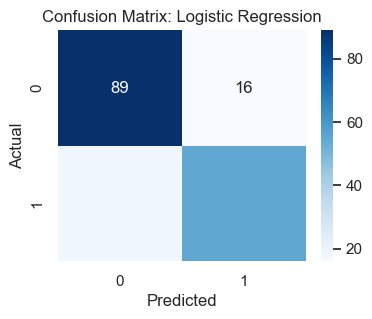

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Make predictions on the test set
y_pred_log = log_reg.predict(X_test)
y_pred_tree = tree_clf.predict(X_test)

# Evaluate Logistic Regression
print("--- Logistic Regression ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_log):.2f}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred_log))

# Evaluate Decision Tree
print("\n--- Decision Tree ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_tree):.2f}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred_tree))

# Confusion Matrix for Logistic Regression
plt.figure(figsize=(4, 3))
sns.heatmap(confusion_matrix(y_test, y_pred_log), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix: Logistic Regression')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

## 10. Model Improvements
We can improve models by tuning fine details called "hyperparameters" (like slightly adjusting the focus knob on a telescope). Also, Decision Trees offer a great feature: they can tell us which features were most "important" in making decisions.

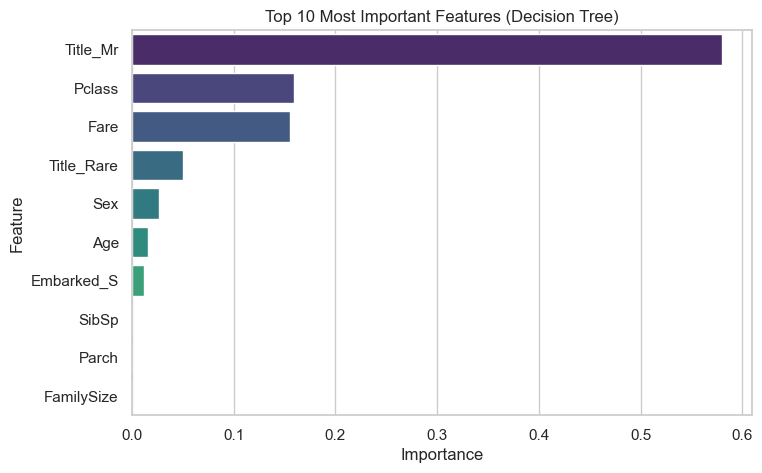


To improve further, we could:
1. Try ensemble models like Random Forest or Gradient Boosting.
2. Create more complex features.
3. Use Grid Search for rigorous hyperparameter tuning.


In [ ]:
# Feature Importance from Decision Tree
importances = tree_clf.feature_importances_
features = X.columns

# Create a DataFrame for visualization
feat_imp = pd.DataFrame({'Feature': features, 'Importance': importances})
feat_imp = feat_imp.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(data=feat_imp.head(10), x='Importance', y='Feature', palette='viridis')
plt.title('Top 10 Most Important Features (Decision Tree)')
plt.show()

print("\nTo improve further, we could:")
print("1. Try ensemble models like Random Forest or Gradient Boosting.")
print("2. Create more complex features.")
print("3. Use Grid Search for rigorous hyperparameter tuning.")